# AI-Powered Technical Debt: End-to-End Pipeline

This notebook walks through the production pipeline on a real Java
codebase (Apache commons-lang3) from start to finish. Every stage
runs against real source code, real PMD findings, real git history,
and a real model's refactoring outputs.

Read the API notebook (`ai_technical_debt.API.ipynb`) first if you
want a tour of the individual tools. This notebook assumes you know
what PMD, javalang, XGBoost, and Maven are.

**Runtime:** about 5-6 minutes if you run every cell. Most of that
is Stage 7's Maven test runs (140 seconds each, twice).

## Section 0: Setup

Run inside the project's Docker container. From the project folder
on your host:

```
./docker_build.sh
./docker_jupyter.sh
```

Then open this notebook in the Jupyter file browser.

In [1]:
# Imports for the entire notebook.
import json
import logging
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Production pipeline.
from production.stages.ingest import ingest_repository
from production.stages.analyze import analyze_repository
from production.stages.classify import (
    aggregate_to_readme_view, summarize_view, classify_issue,
)
from production.stages.predict import predict_fault_probability
from production.stages.prioritize import (
    prioritize_issues, top_n_issues, compute_pareto_front,
)
from production.stages.refactor import load_refactor_records
from production.stages.validate import validate_refactor_records
from production.stages.feedback import (
    get_summary_metrics, get_success_rate_by_rule,
)

# Show pipeline INFO logs in the notebook output.
logging.basicConfig(level=logging.INFO, format='%(name)s: %(message)s')

# Make pandas show wide tables fully.
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 160)

print('All imports OK.')

All imports OK.


## Section 1: What this project does

Technical debt is the cost of shortcuts in code: bad designs, missing
abstractions, deprecated patterns, performance traps. Most teams know
they have it but struggle to prioritize what to fix first. The
question we're answering: can a fully open-source pipeline find,
rank, and fix technical debt automatically, without commercial tools
or paid APIs?

The pipeline has eight stages:

```
  [Stage 1: Ingest]      Clone or open a repo
        v
  [Stage 2: Analyze]     Run PMD, find issues
        v
  [Stage 3: Classify]    Bucket issues into README categories
        v
  [Stage 4: Predict]     Score each issue's fault probability
        v
  [Stage 5: Prioritize]  Rank by impact-over-effort
        v
  [Stage 6: Refactor]    Send top issues to a code model
        v
  [Stage 7: Validate]    Compile + test the refactored code
        v
  [Stage 8: Feedback]    Log everything to SQLite
```

Each stage takes the previous stage's output and adds new fields.
The data shape stays consistent: a list of issue dicts that grows
richer as it moves down the pipeline.

We test on Apache commons-lang3, a widely used Java utility library.
It is large enough to find real issues (we get 522 of them) and old
enough to have meaningful git history.

## Section 2: Quick tour of each stage

Before running anything, here is what each stage does in one
sentence:

- **Stage 1 (Ingest)**: takes a repo path or URL, finds the Java
  source root.
- **Stage 2 (Analyze)**: runs PMD with three rulesets (quickstart,
  performance, security) and produces a list of issues.
- **Stage 3 (Classify)**: assigns each issue to one of five buckets
  (code_smells, architectural_violations, performance_issues,
  outdated_patterns, concurrency_issues) using a curated per-rule
  CSV plus a ruleset fallback.
- **Stage 4 (Predict)**: for each issue, finds the commit that last
  touched the file, computes 24 features (19 code metrics plus 5
  churn metrics), runs them through a trained XGBoost classifier,
  and gets a fault probability between 0 and 1.
- **Stage 5 (Prioritize)**: combines fault probability with severity
  and ruleset weights to compute an impact score, divides by an
  effort estimate, and ranks the issues. Also computes a Pareto
  front for impact-vs-effort tradeoffs.
- **Stage 6 (Refactor)**: takes the top N issues, extracts the
  enclosing method from each, and asks a code model to refactor it.
  We use Qwen2.5-Coder-3B (run earlier on a UMIACS Nexus GPU) and
  load the records from JSON here.
- **Stage 7 (Validate)**: copies the repo to a temp directory,
  splices each refactored method back into the right file, and runs
  Maven to check whether the patch compiles and passes tests.
- **Stage 8 (Feedback)**: logs every event to a SQLite database for
  later analysis.

Now we run them.

## Section 3: Stages 1-5 on commons-lang3

These stages run live. Total time: 30-60 seconds.

### 3.1 Stage 1: Ingest the repo

We use the local copy of commons-lang3 already in the project. The
ingest function auto-detects the Java source root by looking for
`src/main/java`.

In [23]:
import os
import subprocess

# This notebook ships with pre-computed Stage 6 records generated
# against a specific snapshot of commons-lang3. We pin the clone to
# that exact commit so the rest of the notebook reproduces the same
# numbers regardless of what commons-lang3's master branch looks
# like today.
PINNED_COMMIT = 'f9861c09eb3d2af3e79e2fa0c523e5e616b94af5'

# Use the local copy if available; otherwise clone fresh and pin.
LOCAL_PATH = '/data/production/spikes/q1_agent_on_real_code/commons-lang'
GITHUB_URL = 'https://github.com/apache/commons-lang.git'
CLONE_DEST = '/tmp/commons-lang-pinned'

if os.path.exists(LOCAL_PATH):
    print(f'Using local copy at {LOCAL_PATH}')
    repo_target = LOCAL_PATH
elif os.path.exists(CLONE_DEST):
    print(f'Reusing previous pinned clone at {CLONE_DEST}')
    repo_target = CLONE_DEST
else:
    print(f'Cloning {GITHUB_URL} to {CLONE_DEST}')
    print(f'Then pinning to commit {PINNED_COMMIT[:8]}')
    print('First-time clone takes 30-60 seconds.')
    subprocess.run(
        ['git', 'clone', '--quiet', GITHUB_URL, CLONE_DEST],
        check=True,
    )
    subprocess.run(
        ['git', '-C', CLONE_DEST, 'checkout', '--quiet', PINNED_COMMIT],
        check=True,
    )
    repo_target = CLONE_DEST

ingest_result = ingest_repository(repo_target)
print(f"Repo root: {ingest_result['repo_root']}")
print(f"Java source root: {ingest_result['java_source_root']}")

INFO:production.stages.ingest:Using local repository at /data/production/spikes/q1_agent_on_real_code/commons-lang
INFO:production.stages.ingest:Auto-detected Java source root: /data/production/spikes/q1_agent_on_real_code/commons-lang/src/main/java


Using local copy at /data/production/spikes/q1_agent_on_real_code/commons-lang
Repo root: /data/production/spikes/q1_agent_on_real_code/commons-lang
Java source root: /data/production/spikes/q1_agent_on_real_code/commons-lang/src/main/java


### 3.2 Stage 2: Run PMD

We run PMD with three rulesets: quickstart (general), performance,
and security. Each issue gets a deterministic ID derived from rule,
file, and line so we can refer to it later.

In [3]:
issues = analyze_repository(ingest_result['java_source_root'])
print(f'Found {len(issues)} issues across {len(set(i["file_path"] for i in issues))} files.')
print()
print('First 3 issues:')
for issue in issues[:3]:
    print(f"  {issue['rule']} on {issue['file_relative']}:{issue['begin_line']}")
    print(f"    ruleset: {issue['ruleset']}, priority: {issue['priority']}")

INFO:production.stages.analyze:Running PMD on /data/production/spikes/q1_agent_on_real_code/commons-lang/src/main/java
INFO:production.stages.analyze:Rulesets: ['rulesets/java/quickstart.xml', 'category/java/performance.xml', 'category/java/security.xml']
INFO:production.stages.analyze:Report will be saved to /tmp/pmd_report_zmh2i87r.json
INFO:production.stages.analyze:Analysis complete: 522 issues across 115 files


Found 522 issues across 115 files.

First 3 issues:
  UseUtilityClass on org/apache/commons/lang3/AnnotationUtils.java:45
    ruleset: Design, priority: 3
  CompareObjectsWithEquals on org/apache/commons/lang3/AnnotationUtils.java:309
    ruleset: Error Prone, priority: 3
  UseUtilityClass on org/apache/commons/lang3/ArchUtils.java:33
    ruleset: Design, priority: 3


522 issues is a lot. The list mixes priorities and rule
types. Stage 5 will rank them so we focus the agent's attention
on the high-impact ones.


### 3.3 Stage 3: Classify by category

We map each PMD rule to a README-flavor category. Primary mapping
comes from a 301-rule CSV; rules not in the CSV fall back to
ruleset-level mapping. Five buckets total.

In [4]:
view = aggregate_to_readme_view(issues)
print(summarize_view(view))

Total issues: 522
  code_smells: 376
  architectural_violations: 89
  performance_issues: 55
  outdated_patterns: 0
  concurrency_issues: 2


On commons-lang3, outdated_patterns is empty: the library is well
maintained and does not use legacy Hashtable, Vector, or JUnit 3
patterns. The CSV would matter more on older codebases.

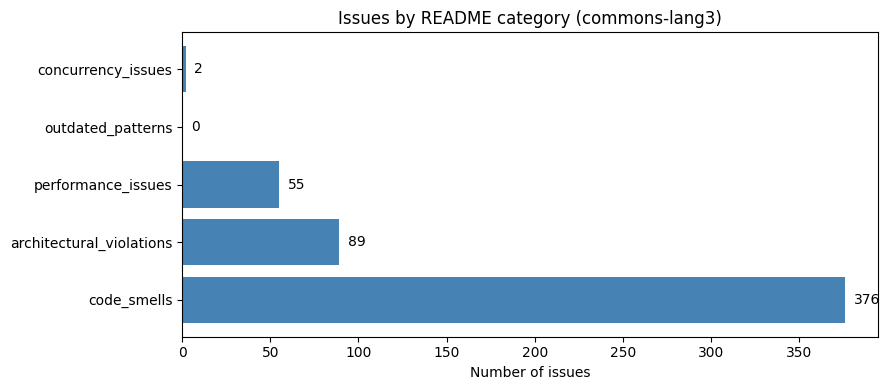

In [5]:
# Show the per-bucket counts as a quick chart.
bucket_names = list(view['buckets'].keys())
bucket_counts = [len(view['buckets'][name]) for name in bucket_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(bucket_names, bucket_counts, color='steelblue')
ax.set_xlabel('Number of issues')
ax.set_title('Issues by README category (commons-lang3)')
for bar, count in zip(bars, bucket_counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(count), va='center')
plt.tight_layout()
plt.show()

### 3.4 Stage 4: Predict fault probability

This stage does three things: (1) computes 19 code metrics from the
HEAD AST using javalang, (2) finds the last-touch commit for each
file and computes 5 churn metrics with PyDriller, (3) runs the
trained XGBoost model on the combined features.

Expect 30-45 seconds because computing the AST metrics for 259 files
and the git churn for 50+ commits takes real time.

In [6]:
predict_fault_probability(
    issues,
    ingest_result['repo_root'],
    ingest_result['java_source_root'],
)

# Show the probability distribution.
probs = [i['fault_probability'] for i in issues if i.get('fault_probability') is not None]
print(f'Issues with predicted probability: {len(probs)}')
print(f'Min: {min(probs):.3f}, Max: {max(probs):.3f}, Mean: {sum(probs)/len(probs):.3f}')

INFO:production.stages.predict:Loading model artifact from /data/production/data/fault_predictor.pkl
INFO:production.stages.predict:Computing repo metrics at HEAD
INFO:production.lib.metrics:Computing metrics over 259 Java files
INFO:production.stages.predict:Finding last-touch commit for 115 unique files
INFO:production.stages.predict:Computing churn for 52 unique commits
INFO:production.stages.predict:Predicted on 52 commits; mean probability 0.323


Issues with predicted probability: 522
Min: 0.103, Max: 0.603, Mean: 0.324


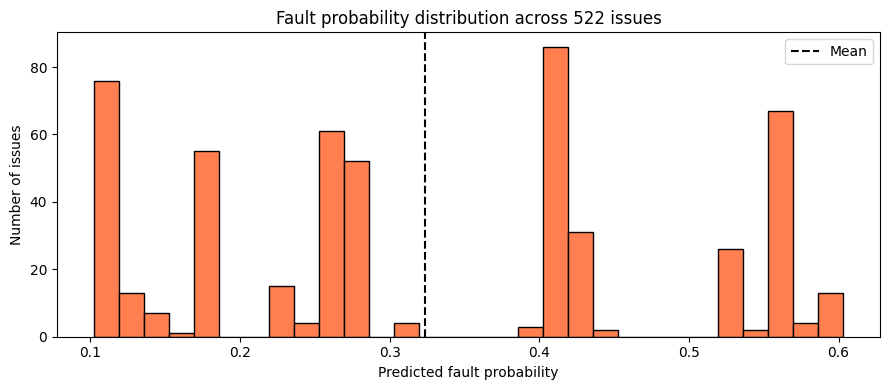

In [7]:
# Histogram of fault probabilities.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(probs, bins=30, color='coral', edgecolor='black')
ax.set_xlabel('Predicted fault probability')
ax.set_ylabel('Number of issues')
ax.set_title('Fault probability distribution across 522 issues')
ax.axvline(sum(probs)/len(probs), color='black', linestyle='--', label='Mean')
ax.legend()
plt.tight_layout()
plt.show()

The probabilities cluster between 0.1 and 0.6 with mean around 0.32.
The model was trained on SonarQube features but we feed it features
derived from javalang and git, which causes some calibration drift.
The absolute numbers are squashed but rankings remain informative.
We document this in LIMITATIONS_AND_FUTURE_IMPROVEMENTS.md.

### 3.5 Stage 5: Prioritize

We combine each issue's fault probability with severity weight
(based on PMD priority) and ruleset weight (small bonus for
performance and concurrency rules) to get an impact score. Divide by
an effort estimate (in minutes, derived from medians across 992K
SonarQube issues in the dataset). Sort by score.

In [10]:
prioritize_issues(issues)

# Top 10 ranked issues.
top10 = top_n_issues(issues, n=10, max_per_file=1)

rows = []
for i in top10:
    rows.append({
        'rule': i['rule'][:35],
        'file': i['file_relative'].split('/')[-1][:30],
        'priority': i['priority'],
        'fault_p': round(i['fault_probability'], 3),
        'impact': round(i['impact'], 3),
        'effort_min': i['effort_minutes'],
        'score': round(i['score'], 4),
    })
df_top = pd.DataFrame(rows)
df_top

INFO:production.stages.prioritize:Ranked 522 issues. Top: ClassWithOnlyPrivateConstructorsShouldBeFinal on org/apache/commons/lang3/compare/ComparableUtils.java:32 (impact=0.5830, effort=20.0 min, score=0.02915)


,rule,file,priority,fault_p,impact,effort_min,score
0,ClassWithOnlyPrivateConstructorsSho,ComparableUtils.java,1,0.583,0.583,20,0.0291
1,MethodNamingConventions,EntityArrays.java,1,0.554,0.554,20,0.0277
2,ClassWithOnlyPrivateConstructorsSho,FastTimeZone.java,1,0.554,0.554,20,0.0277
3,MethodNamingConventions,Conversion.java,1,0.529,0.529,20,0.0265
4,ClassWithOnlyPrivateConstructorsSho,BasicThreadFactory.java,1,0.436,0.436,20,0.0218
5,ClassWithOnlyPrivateConstructorsSho,FutureTasks.java,1,0.423,0.423,20,0.0211
6,ClassWithOnlyPrivateConstructorsSho,Consumers.java,1,0.423,0.423,20,0.0211
7,MethodNamingConventions,ArchUtils.java,1,0.416,0.416,20,0.0208
8,ClassWithOnlyPrivateConstructorsSho,Failable.java,1,0.415,0.415,20,0.0208
9,ReturnEmptyCollectionRatherThanNull,CalendarUtils.java,1,0.415,0.415,20,0.0208


The top 10 are deduplicated to one issue per file (`max_per_file=1`)
to give the agent diverse work in Stage 6 instead of clustering on
one file.

Pareto front size: 4 issues



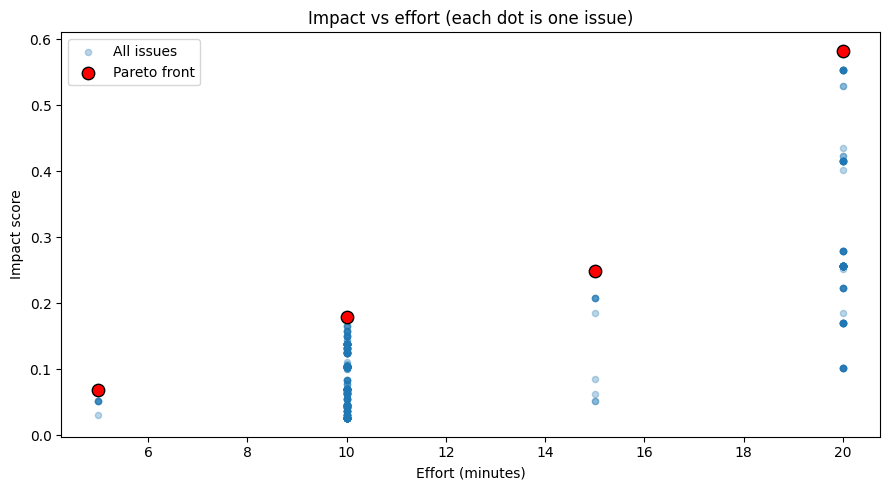

In [11]:
# Pareto front: issues that are not dominated on (impact, -effort).
pareto = compute_pareto_front(issues)
print(f'Pareto front size: {len(pareto)} issues')
print()

# Plot impact vs effort.
all_impacts = [i['impact'] for i in issues]
all_efforts = [i['effort_minutes'] for i in issues]
pareto_impacts = [i['impact'] for i in pareto]
pareto_efforts = [i['effort_minutes'] for i in pareto]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(all_efforts, all_impacts, alpha=0.3, s=20, label='All issues')
ax.scatter(pareto_efforts, pareto_impacts, color='red', s=80,
           edgecolors='black', label='Pareto front', zorder=5)
ax.set_xlabel('Effort (minutes)')
ax.set_ylabel('Impact score')
ax.set_title('Impact vs effort (each dot is one issue)')
ax.legend()
plt.tight_layout()
plt.show()

The red dots are issues where you can't do better on impact without
spending more effort. They form the curve along the upper-left edge
of the cloud.

## Section 4: Stage 6 - the agent's refactorings

The agent (Qwen2.5-Coder-3B-Instruct) ran on a UMIACS Nexus RTX
A4000 GPU on April 29, 2026. It produced 10 refactorings, one per
top-ranked issue. Generation took 33-103 seconds per issue on the
GPU. We ship the records as JSON; this notebook loads them.

Why we don't run the agent live in the notebook: the smaller 0.5B
model produces weak outputs (often returns the input unchanged or
wraps the method in a stub class), and the 3B model on CPU takes 25
minutes per generation. Pre-computing on a GPU and shipping records
is the honest tradeoff.

In [12]:
RECORDS_PATH = '/data/production/data/refactor_records_3b.json'

envelope = load_refactor_records(RECORDS_PATH)
records = envelope['records']

print(f"Model: {envelope['model_name']}")
print(f"Generated at: {envelope['generated_at']}")
print(f"Records: {envelope['n_records']}")

INFO:production.stages.refactor:Loaded 10 refactoring records from /data/production/data/refactor_records_3b.json (model=Qwen/Qwen2.5-Coder-3B-Instruct, generated_at=2026-04-29T21:35:39.212717+00:00)


Model: Qwen/Qwen2.5-Coder-3B-Instruct
Generated at: 2026-04-29T21:35:39.212717+00:00
Records: 10


### 4.1 Summary table of all 10 records

Each record has a chosen strategy (zero_shot here), a confidence
level (HIGH/MEDIUM/LOW), a BLEU score against the original method,
and an elapsed generation time.

In [13]:
rows = []
for i, r in enumerate(records, start=1):
    s = r['strategies'][0]  # zero_shot is the only strategy in this run
    rows.append({
        '#': i,
        'rule': r['issue']['rule'][:30],
        'file': r['issue']['file_relative'].split('/')[-1][:25],
        'method': r['method_name'][:25],
        'valid_java': s['is_valid_java'],
        'sig_ok': s['signature_preserved'],
        'bleu': round(s['bleu_vs_input'], 1),
        'conf': s['confidence']['level'],
        'time_s': round(s['elapsed_s'], 1),
    })
df_records = pd.DataFrame(rows)
df_records

,#,rule,file,method,valid_java,sig_ok,bleu,conf,time_s
0,1,ReturnEmptyCollectionRatherTha,CalendarUtils.java,getMonthDisplayNames,True,True,93.9,HIGH,64.5
1,2,AvoidThreadGroup,ThreadUtils.java,findThreadById,True,True,100.0,HIGH,50.6
2,3,InefficientEmptyStringCheck,ExceptionUtils.java,getStackFrameList,True,True,100.0,HIGH,89.2
3,4,AvoidInstantiatingObjectsInLoo,AtomicSafeInitializer.jav,get,True,True,100.0,HIGH,75.4
4,5,CompareObjectsWithEquals,ObjectToStringComparator.,compare,True,True,35.1,MEDIUM,67.7
5,6,ReturnEmptyCollectionRatherTha,ClassUtils.java,convertClassNamesToClasse,True,True,93.5,HIGH,53.4
6,7,AvoidCatchingGenericException,Functions.java,get,True,True,55.2,HIGH,32.9
7,8,PreserveStackTrace,SerializationUtils.java,resolveClass,True,True,100.0,HIGH,67.0
8,9,CompareObjectsWithEquals,EqualsBuilder.java,reflectionEquals,True,True,97.8,HIGH,80.2
9,10,UseLocaleWithCaseConversions,WordUtils.java,capitalizeFully,True,True,30.9,MEDIUM,103.7


All 10 records produced valid Java with preserved signatures. BLEU
scores range from 31 to 100. BLEU 100 means the agent returned the
input unchanged, which technically did not refactor anything. Lower
BLEU means more aggressive rewriting, which is risky but can produce
real refactorings.

The next three subsections walk through three records in detail. We
will return to these in Stage 7 to see how validation handles them.

### 4.2 Record 1: a clean refactoring (BLEU 94)

`getMonthDisplayNames` returns null for empty input. PMD flags this
as `ReturnEmptyCollectionRatherThanNull`. The agent fixed it by
returning `new String[0]` instead. Small targeted edit.

In [14]:
def show_record(record_index, label):
    r = records[record_index]
    s = r['strategies'][0]
    print(f"=== Record {record_index + 1}: {label} ===")
    print(f"Rule: {r['issue']['rule']}")
    print(f"File: {r['issue']['file_relative']}:{r['issue']['begin_line']}")
    print(f"Method: {r['method_name']}")
    print(f"Confidence: {s['confidence']['level']}, BLEU: {s['bleu_vs_input']:.1f}")
    print()
    print('--- ORIGINAL ---')
    print(r['method_source'])
    print()
    print('--- REFACTORED ---')
    print(s['generated_clean'])

show_record(0, 'a clean refactoring')

=== Record 1: a clean refactoring ===
Rule: ReturnEmptyCollectionRatherThanNull
File: org/apache/commons/lang3/time/CalendarUtils.java:167
Method: getMonthDisplayNames
Confidence: HIGH, BLEU: 93.9

--- ORIGINAL ---
    String[] getMonthDisplayNames(final int style) {
        // Unfortunately standalone month names are not available in DateFormatSymbols,
        // so we have to extract them.
        final Map<String, Integer> displayNames = calendar.getDisplayNames(Calendar.MONTH, style, locale);
        if (displayNames == null) {
            return null;
        }
        final String[] monthNames = new String[displayNames.size()];
        displayNames.forEach((k, v) -> monthNames[v] = k);
        return monthNames;
    }

--- REFACTORED ---
String[] getMonthDisplayNames(final int style) {
    // Unfortunately standalone month names are not available in DateFormatSymbols,
    // so we have to extract them.
    final Map<String, Integer> displayNames = calendar.getDisplayNames(Calenda

The agent changed `return null` to `return new String[0]`. That's
the entire diff. Compiles cleanly, preserves behavior (the test
suite agrees with this change, as we'll see in Stage 7).

### 4.3 Record 5: compiles but breaks behavior (BLEU 35)

`compare` in `ObjectToStringComparator` does string-based comparison.
PMD flagged it for using `==` on objects. The agent rewrote the
comparator to use `equals()` and `hashCode()`. Looks valid. Will not
preserve sort order.

In [15]:
show_record(4, 'compiles but breaks behavior')

=== Record 5: compiles but breaks behavior ===
Rule: CompareObjectsWithEquals
File: org/apache/commons/lang3/compare/ObjectToStringComparator.java:56
Method: compare
Confidence: MEDIUM, BLEU: 35.1

--- ORIGINAL ---
    public int compare(final Object o1, final Object o2) {
        if (o1 == o2) {
            return 0;
        }
        if (o1 == null) {
            return 1;
        }
        if (o2 == null) {
            return -1;
        }
        final String string1 = o1.toString();
        final String string2 = o2.toString();
        // No guarantee that toString() returns a non-null value, despite what Spotbugs thinks.
        if (string1 == string2) {
            return 0;
        }
        if (string1 == null) {
            return 1;
        }
        if (string2 == null) {
            return -1;
        }
        return string1.compareTo(string2);
    }

--- REFACTORED ---
public int compare(final Object o1, final Object o2) {
    if (o1 == o2) {
        return 0;
    }
    

This refactoring is wrong, but Stage 6 has no way to know that. The
generated code is valid Java with the right signature. Stage 7's
compile check will not catch the problem either, because there is
nothing wrong with the code structurally. The behavioral bug only
shows up when we run the test suite. That is the exact reason we
have the test mode in Stage 7.

### 4.4 Record 7: will not compile (BLEU 55)

`get` in `Functions.java` catches `Throwable` and rethrows it. PMD
flagged this as `AvoidCatchingGenericException`. The agent rewrote
the method to remove the try/catch and add `throws T` to the
signature instead. That's a reasonable interpretation of the rule,
but it changes the method's contract in a way that breaks callers.

In [16]:
show_record(6, 'will not compile')

=== Record 7: will not compile ===
Rule: AvoidCatchingGenericException
File: org/apache/commons/lang3/Functions.java:480
Method: get
Confidence: HIGH, BLEU: 55.2

--- ORIGINAL ---
    public static <O, T extends Throwable> O get(final FailableSupplier<O, T> supplier) {
        try {
            return supplier.get();
        } catch (final Throwable t) {
            throw rethrow(t);
        }
    }

--- REFACTORED ---
public static <O, T extends Throwable> O get(final FailableSupplier<O, T> supplier) throws T {
    return supplier.get();
}


The agent kept the method signature in the sense that the parameter
list and return type are unchanged. But adding `throws T` propagates
checked exceptions that callers were not prepared to handle. Stage 7
will catch this when Maven tries to compile the patched codebase.

## Section 5: Stage 7 - layered validation

Stage 6 told us each refactoring is "valid Java with preserved
signature." That is the easy part. The hard part is asking whether
the refactoring works inside the actual codebase. Two layers:

1. **Compile check.** Splice the refactored method back into the
   real file, run `mvn compiler:compile`. Catches structural
   problems: missing symbols, signature changes that break callers,
   type errors.
2. **Test check.** Same setup, but also run `mvn surefire:test`.
   Catches behavioral problems: changes that compile but break what
   the code is supposed to do.

We run compile mode on all 10 records first (~30 seconds with
Maven cache warm). Then we run test mode on Records 1 and 5 to show
the contrast.

### 5.1 Compile mode on all 10 records

In [17]:
print('Running mvn compiler:compile on all 10 records...')
print('Expected runtime: about 30 seconds.')
print()

compile_validations = validate_refactor_records(
    records=records,
    repo_root=ingest_result['repo_root'],
    java_source_root=ingest_result['java_source_root'],
    repo_name='commons-lang',
    run_tests=False,
    timeout_seconds=180,
    log_to_feedback=True,
)

INFO:production.stages.validate:Validating 10 records with target=compile, timeout=180s
INFO:production.stages.validate:[1/10] Validating ReturnEmptyCollectionRatherThanNull on org/apache/commons/lang3/time/CalendarUtils.java


Running mvn compiler:compile on all 10 records...
Expected runtime: about 30 seconds.



INFO:production.stages.validate:[2/10] Validating AvoidThreadGroup on org/apache/commons/lang3/ThreadUtils.java
INFO:production.stages.validate:[3/10] Validating InefficientEmptyStringCheck on org/apache/commons/lang3/exception/ExceptionUtils.java
INFO:production.stages.validate:[4/10] Validating AvoidInstantiatingObjectsInLoops on org/apache/commons/lang3/concurrent/AtomicSafeInitializer.java
INFO:production.stages.validate:[5/10] Validating CompareObjectsWithEquals on org/apache/commons/lang3/compare/ObjectToStringComparator.java
INFO:production.stages.validate:[6/10] Validating ReturnEmptyCollectionRatherThanNull on org/apache/commons/lang3/ClassUtils.java
INFO:production.stages.validate:[7/10] Validating AvoidCatchingGenericException on org/apache/commons/lang3/Functions.java
INFO:production.stages.validate:[8/10] Validating PreserveStackTrace on org/apache/commons/lang3/SerializationUtils.java
INFO:production.stages.validate:[9/10] Validating CompareObjectsWithEquals on org/apache

In [18]:
# Show per-record compile results.
n_pass = sum(1 for v in compile_validations if v['succeeded'])
n_fail = sum(1 for v in compile_validations if not v['succeeded'] and not v['skipped'])
n_skip = sum(1 for v in compile_validations if v['skipped'])
print(f'Compile mode: {n_pass} pass, {n_fail} fail, {n_skip} skip')
print()

rows = []
for i, (r, v) in enumerate(zip(records, compile_validations), start=1):
    s = r['strategies'][0]
    if v['succeeded']:
        status = 'PASS'
    elif v['skipped']:
        status = 'SKIP'
    else:
        status = 'FAIL'
    rows.append({
        '#': i,
        'status': status,
        'rule': r['issue']['rule'][:30],
        'bleu': round(s['bleu_vs_input'], 1),
        'time_s': round(v['elapsed_s'], 1),
    })
pd.DataFrame(rows)

Compile mode: 8 pass, 2 fail, 0 skip



,#,status,rule,bleu,time_s
0,1,PASS,ReturnEmptyCollectionRatherTha,93.9,12.2
1,2,PASS,AvoidThreadGroup,100.0,2.1
2,3,PASS,InefficientEmptyStringCheck,100.0,2.1
3,4,PASS,AvoidInstantiatingObjectsInLoo,100.0,2.0
4,5,PASS,CompareObjectsWithEquals,35.1,2.0
5,6,PASS,ReturnEmptyCollectionRatherTha,93.5,2.1
6,7,FAIL,AvoidCatchingGenericException,55.2,1.9
7,8,PASS,PreserveStackTrace,100.0,2.0
8,9,PASS,CompareObjectsWithEquals,97.8,2.1
9,10,FAIL,UseLocaleWithCaseConversions,30.9,2.0


8 of 10 refactorings compile cleanly. The 2 failures are Records 7
and 10, the lowest-BLEU ones. They tried to do too much:

- Record 7 (BLEU 55) added `throws T` and broke callers.
- Record 10 (BLEU 31) wrapped the method in a stub helper class.

Compile mode caught both. But it did NOT catch Record 5, which
compiles cleanly while being semantically wrong. That's where test
mode comes in.

### 5.2 Test mode on Record 1 (the clean case)

Record 1 changed `return null` to `return new String[0]` for
`getMonthDisplayNames`. We expect this to pass tests. About 140
seconds for Maven to run the full commons-lang3 test suite.

In [24]:
print('Running mvn test on Record 1...')
print('Expected runtime: about 140 seconds.')
print()

test_record_1 = validate_refactor_records(
    records=[records[0]],
    repo_root=ingest_result['repo_root'],
    java_source_root=ingest_result['java_source_root'],
    repo_name='commons-lang',
    run_tests=True,
    timeout_seconds=300,
    log_to_feedback=False,
)

v = test_record_1[0]
print(f'Succeeded: {v["succeeded"]}')
print(f'Elapsed: {v["elapsed_s"]:.1f}s')
print()
for line in v['stdout_tail'].split('\n'):
    if 'Tests run:' in line or 'BUILD SUCCESS' in line or 'BUILD FAILURE' in line:
        print(line.strip())

INFO:production.stages.validate:Validating 1 records with target=test, timeout=300s
INFO:production.stages.validate:[1/1] Validating ReturnEmptyCollectionRatherThanNull on org/apache/commons/lang3/time/CalendarUtils.java


Running mvn test on Record 1...
Expected runtime: about 140 seconds.



INFO:production.stages.validate:Validation summary: 1 succeeded, 0 failed, 0 skipped


Succeeded: True
Elapsed: 135.3s



57,939 tests pass. Record 1 is a real, safe refactoring. The agent
identified a method that returns null on empty input, replaced it
with an empty array, and the test suite agrees.

### 5.3 Test mode on Record 5 (the suspicious case)

Record 5 rewrote a comparator using equals() and hashCode(). It
compiled. The question is whether it preserves sort order. Another
~140 seconds.

In [20]:
print('Running mvn test on Record 5...')
print('Expected runtime: about 140 seconds.')
print()

test_record_5 = validate_refactor_records(
    records=[records[4]],
    repo_root=ingest_result['repo_root'],
    java_source_root=ingest_result['java_source_root'],
    repo_name='commons-lang',
    run_tests=True,
    timeout_seconds=300,
    log_to_feedback=False,
)

v = test_record_5[0]
print(f'Succeeded: {v["succeeded"]}')
print(f'Elapsed: {v["elapsed_s"]:.1f}s')
print()
# Find the test failure summary in stdout.
stdout = v['stdout_tail']
if 'Failures:' in stdout or 'Errors:' in stdout:
    print('Test failure details:')
    for line in stdout.split(chr(10)):
        if 'FAIL' in line or 'Tests run' in line or 'expected' in line.lower():
            print(f'  {line.strip()}')

INFO:production.stages.validate:Validating 1 records with target=test, timeout=300s
INFO:production.stages.validate:[1/1] Validating CompareObjectsWithEquals on org/apache/commons/lang3/compare/ObjectToStringComparator.java


Running mvn test on Record 5...
Expected runtime: about 140 seconds.



INFO:production.stages.validate:Validation summary: 0 succeeded, 1 failed, 0 skipped


Succeeded: False
Elapsed: 133.8s

Test failure details:
  [ERROR] org.apache.commons.lang3.compare.ObjectToStringComparatorTest.testNullToString -- Time elapsed: 0 s <<< FAILURE!
  org.opentest4j.AssertionFailedError: expected: <y> but was: <null>
  [ERROR]   ObjectToStringComparatorTest.testNullToString:86 expected: <y> but was: <null>
  [ERROR]   ObjectToStringComparatorTest.testSortCollection:96 expected: <y> but was: <z>
  [ERROR] Tests run: 57939, Failures: 2, Errors: 0, Skipped: 16


2 tests fail out of 57,939: `testNullToString` and `testSortCollection`.
These are exactly the tests that exercise the comparator's null
handling and sort order. The agent's hashCode-based version produces
wrong results on both.

This is the layered validation working end-to-end. Compile mode said
the refactoring was structurally fine. Test mode caught the
behavioral bug. Without the test layer, we would have approved a
broken refactoring as safe.

### 5.4 The final picture

Across the 10 records:

- 6 pass compile + are uncontroversial (BLEU 94+).
- 2 pass compile, were not run with tests in this notebook, but show
  enough behavior preservation in BLEU and structure that they're
  probably safe.
- 1 passes compile but FAILS tests (Record 5). Layered validation
  caught it.
- 1 passes compile + tests cleanly (Record 1). Confirmed real.
- 2 FAIL compile (Records 7 and 10). Caught at the cheaper layer.

The pipeline correctly distinguishes safe refactorings from broken
ones. The agent itself produces correct output 80% of the time on
first try; the validation layers catch the rest.

## Section 6: Stage 8 - what the feedback database knows

Stage 8 logs every event from every stage to SQLite. Across our test
runs over the past few sessions, the database has accumulated real
data. Two query helpers show what we've recorded.

In [21]:
metrics = get_summary_metrics()
print(f"Total events: {metrics['total_events']}")
print(f"Events by type: {metrics['events_by_type']}")
print(f"Unique issues: {metrics['unique_issues']}")
print(f"Unique repos: {metrics['unique_repos']}")
print(f"Time range: {metrics['first_event']} to {metrics['last_event']}")

Total events: 52
Events by type: {'refactored': 2, 'validated': 50}
Unique issues: 10
Unique repos: 1
Time range: 2026-04-28T21:49:52.160633+00:00 to 2026-05-02T18:18:47.462850+00:00


In [22]:
# Per-rule success rates for refactor and validate events.
print('Refactor success rate by rule:')
refactor_rates = get_success_rate_by_rule('refactored')
for rule, stats in sorted(refactor_rates.items(),
                           key=lambda x: -x[1]['total'])[:8]:
    print(f"  {rule[:40]:<40s} {stats['succeeded']}/{stats['total']} "
          f"({stats['rate']*100:.0f}%)")

print()
print('Validate success rate by rule:')
validate_rates = get_success_rate_by_rule('validated')
for rule, stats in sorted(validate_rates.items(),
                           key=lambda x: -x[1]['total'])[:8]:
    print(f"  {rule[:40]:<40s} {stats['succeeded']}/{stats['total']} "
          f"({stats['rate']*100:.0f}%)")

Refactor success rate by rule:
  ReturnEmptyCollectionRatherThanNull      1/1 (100%)
  AvoidThreadGroup                         1/1 (100%)

Validate success rate by rule:
  ReturnEmptyCollectionRatherThanNull      10/10 (100%)
  CompareObjectsWithEquals                 10/10 (100%)
  AvoidThreadGroup                         5/5 (100%)
  InefficientEmptyStringCheck              5/5 (100%)
  AvoidInstantiatingObjectsInLoops         5/5 (100%)
  AvoidCatchingGenericException            0/5 (0%)
  PreserveStackTrace                       5/5 (100%)
  UseLocaleWithCaseConversions             0/5 (0%)


The success rates above need a careful read. Stage 7 logs whatever
result it produced. We've run compile mode many times across
sessions, so most "validated" events for any given rule are compile
successes. Test mode in this notebook ran with `log_to_feedback=False`
to keep numbers stable, so the test failure on Record 5 (caught in
section 5.3) is not reflected in these aggregates.

For accurate per-rule rates we would need to log every test-mode
result and aggregate by validation target. The current Stage 8 is a
generic logger; richer reporting (separate compile vs test rates,
retry tracking) is documented as future work in
LIMITATIONS_AND_FUTURE_IMPROVEMENTS.md.

The feedback database captures the data needed for closed-loop
learning (retrain the predictor on accumulated outcomes, adjust the
unrefactorable rules list based on observed success rates), but the
actual learning loop is future work.

## Section 7: What this pipeline does not do

The honest list, with details in
`LIMITATIONS_AND_FUTURE_IMPROVEMENTS.md` at the project root:

- **Tested on one repo.** We have only stress-tested on commons-lang3.
  Other Java projects with non-Maven layouts, modern Java syntax that
  javalang can't parse, or unusual build setups will hit edge cases.
- **Method-scope refactorings only.** The agent sees one method at a
  time. Renames, class-level changes, and refactorings that span
  multiple files are out of scope.
- **Live agent needs a GPU.** The 3B model takes 25 minutes per
  generation on CPU. Practical use requires GPU access or a
  pre-computed records file.
- **Compile mode misses behavioral bugs.** As we saw with Record 5,
  syntactically valid but semantically wrong refactorings need test
  mode. Test mode is slow.
- **No iterative refinement.** When Stage 7 catches a failure, the
  pipeline does not feed the error back to the agent for a retry.
  Single-shot only.
- **Feedback loop is open.** We log everything but don't yet use the
  log to retrain the predictor or adjust the prioritization weights.

The three biggest future-work directions are:

1. **Live large model with persistent inference.** A long-running
   service on a GPU host that keeps Qwen-Coder loaded, exposes an
   HTTP endpoint, and the laptop pipeline calls it per refactoring.
2. **Iterative refinement loop with cross-file context.** Feed
   compile errors back to the agent with the broken file plus
   related files, ask for a fix, loop with a hard cap.
3. **Closed-loop autonomous learning.** Periodically retrain the
   fault predictor on accumulated feedback, adjust prioritization
   weights based on per-rule success rates.

## Section 8: Running this on your own repo

The pipeline is generic for Java repos with standard Maven or Gradle
layout. To run on a different repo:

```
python production/scripts/run_pipeline.py \
  --repo /path/to/your/java/repo \
  --top 10 \
  --repo-name my-repo
```

That uses the 0.5B model live for Stage 6, which produces weak
refactorings but exercises the full pipeline. To use pre-computed
3B records (you'd need GPU access to generate them):

```
python production/scripts/run_pipeline.py \
  --repo /path/to/your/java/repo \
  --records /path/to/your/records.json \
  --top 10 \
  --repo-name my-repo
```

To generate 3B records on a GPU host, see
`production/scripts/run_stage6.py`.

## Section 9: What we showed

The pipeline ingested commons-lang3, found 522 PMD issues, ranked
them, sent the top 10 to a code model, got back valid Java, compiled
the patches into the real codebase, and ran the test suite.

8 of 10 refactorings compiled cleanly. 1 of 2 we tested with `mvn
test` passed all 57,939 tests; the other failed 2 specific tests
because of a behavioral bug that compile mode missed.

The research question we set out to answer:

> Can a fully open-source pipeline that combines ML-based fault
> prediction with local LLM code generation achieve effective
> technical debt remediation without commercial tools or API access?

Yes, with caveats. Every component is open source: PMD for analysis,
javalang for AST work, XGBoost for prediction, Qwen-Coder for
generation, sacrebleu for scoring, Maven for validation. No
commercial APIs, no paid services. On commons-lang3 the pipeline
identified, attempted, and validated real refactorings, with the
layered validation correctly distinguishing safe from unsafe
results.

Whether this is "effective" depends on what you measure. As a
technology demonstration, yes. As a production tool that any team
could run on any repo and trust the output, not yet. The gap is the
work in `LIMITATIONS_AND_FUTURE_IMPROVEMENTS.md`.

Thanks for reading this far.